<a href="https://colab.research.google.com/github/ekyaaa/pengolahan-citra/blob/main/Week07_Case_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MODUL 7 – Case Method 1**

In [1]:
from google.colab import drive

drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Mounted at /content/drive


# **Bagian A – Observasi & Eksperimen**

## **0. Inisiasi**

### Variabel

In [2]:
path1 = '/content/drive/MyDrive/Case_Method_IMG/pcvk_case_study_img/face1.jpeg'
path2 = '/content/drive/MyDrive/Case_Method_IMG/pcvk_case_study_img/face2.jpeg'
path3 = '/content/drive/MyDrive/Case_Method_IMG/pcvk_case_study_img/face3.jpeg'

img1 = cv.imread(path1)
img2 = cv.imread(path2)
img3 = cv.imread(path3)

if img1 is None or img2 is None or img3 is None:
    raise FileNotFoundError("Satu atau lebih file gambar tidak ditemukan. Cek kembali path file.")

images = {
    "Citra 1: Side-Lighting": img1,
    "Citra 2: Well-Exposed": img2,
    "Citra 3: Underexposed": img3
}

### Fungsi Dasar

In [3]:
# Fungsi untuk menampilkan perbandingan gambar
def show_comparison(title1, image1, title2, image2, is_gray=False):
    """Menampilkan dua gambar berdampingan untuk perbandingan."""
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title(title1)
    if is_gray: plt.imshow(image1, cmap='gray')
    else: plt.imshow(cv.cvtColor(image1, cv.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(title2)
    if is_gray: plt.imshow(image2, cmap='gray')
    else: plt.imshow(cv.cvtColor(image2, cv.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Fungsi untuk menampilkan histogram dengan perbandingan
def show_histogram_comparison(image1, image2, is_gray=False, title1="Before", title2="After"):
    """
    Menampilkan histogram dari dua gambar berdampingan di satu baris.
    """
    plt.figure(figsize=(12, 4))

    # Histogram gambar pertama
    plt.subplot(1, 2, 1)
    if is_gray:
        hist1 = cv.calcHist([image1], [0], None, [256], [0, 256])
        plt.plot(hist1, color='black')
    else:
        colors = ('b', 'g', 'r')
        for i, color in enumerate(colors):
            hist1 = cv.calcHist([image1], [i], None, [256], [0, 256])
            plt.plot(hist1, color=color)
    plt.title(f'Histogram {title1}')
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.5)

    # Histogram gambar kedua
    plt.subplot(1, 2, 2)
    if is_gray:
        hist2 = cv.calcHist([image2], [0], None, [256], [0, 256])
        plt.plot(hist2, color='black')
    else:
        colors = ('b', 'g', 'r')
        for i, color in enumerate(colors):
            hist2 = cv.calcHist([image2], [i], None, [256], [0, 256])
            plt.plot(hist2, color=color)
    plt.title(f'Histogram {title2}')
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Fungsi untuk menampilkan gambar dengan RGB
def show_image_with_rgb_histogram(title, image):
    """Menampilkan gambar di kiri dan histogram RGB-nya di kanan."""
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    colors = ('b', 'g', 'r')
    channel_names = ('Blue', 'Green', 'Red')
    for i, color in enumerate(colors):
        hist = cv.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=color, label=channel_names[i])
    plt.title('Histogram RGB')
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Fungsi untuk menampilkan gambar dengan grayscale
def show_grayscale_and_hist(title, gray_image):
    """Menampilkan gambar grayscale dan histogramnya berdampingan."""
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(gray_image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.subplot(1, 2, 2)
    hist = cv.calcHist([gray_image], [0], None, [256], [0, 256])
    plt.plot(hist, color='black')
    plt.title('Histogram Grayscale')
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 256])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


## 1. Tampilkan histogram tiap citra dan analisis distribusi intensitasnya.

Hasil Analisis:
*   Semakin ke kiri semakin gelap dan semakin ke kanan semakin terang.
*   Semakin nilai warna di image semakin tinggi juga grafik pada x yang menggambarkan nilai warna itu(0-255).



In [4]:
def task_1_analyze_histograms(images_dict):
    """Tugas 1: Menampilkan histogram RGB untuk setiap citra."""
    print("--- 1. Analisis Histogram ---")
    for title, img in images_dict.items():
        show_image_with_rgb_histogram(title, img)

### Implementasi/Hasil

--- 1. Analisis Histogram ---


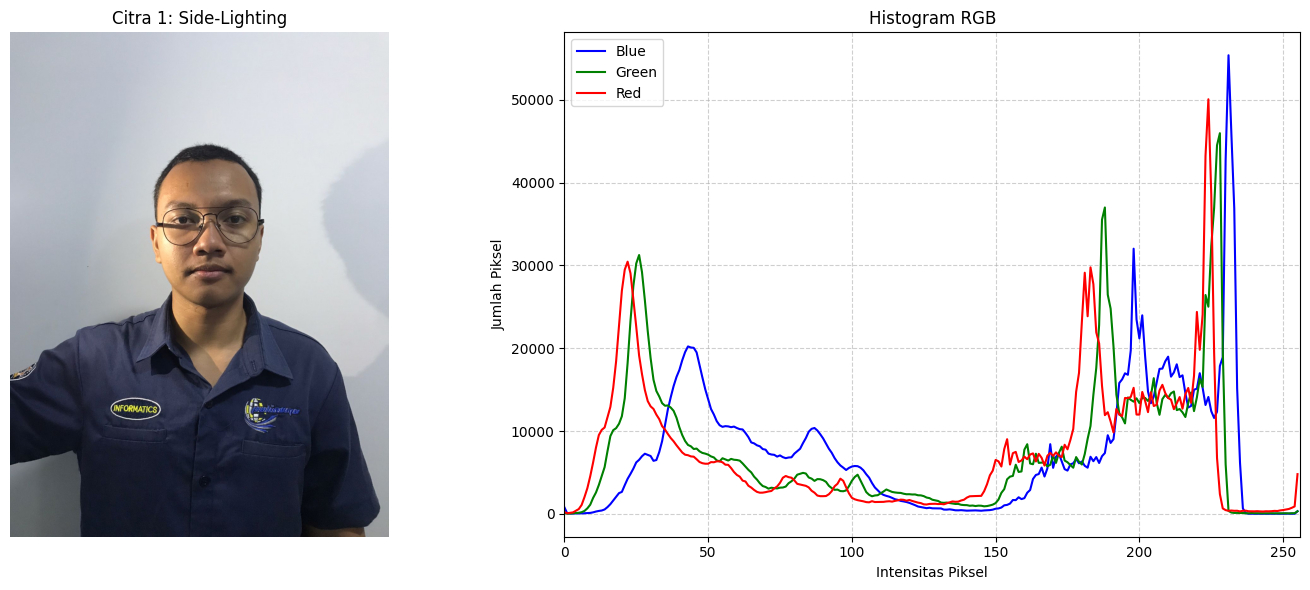

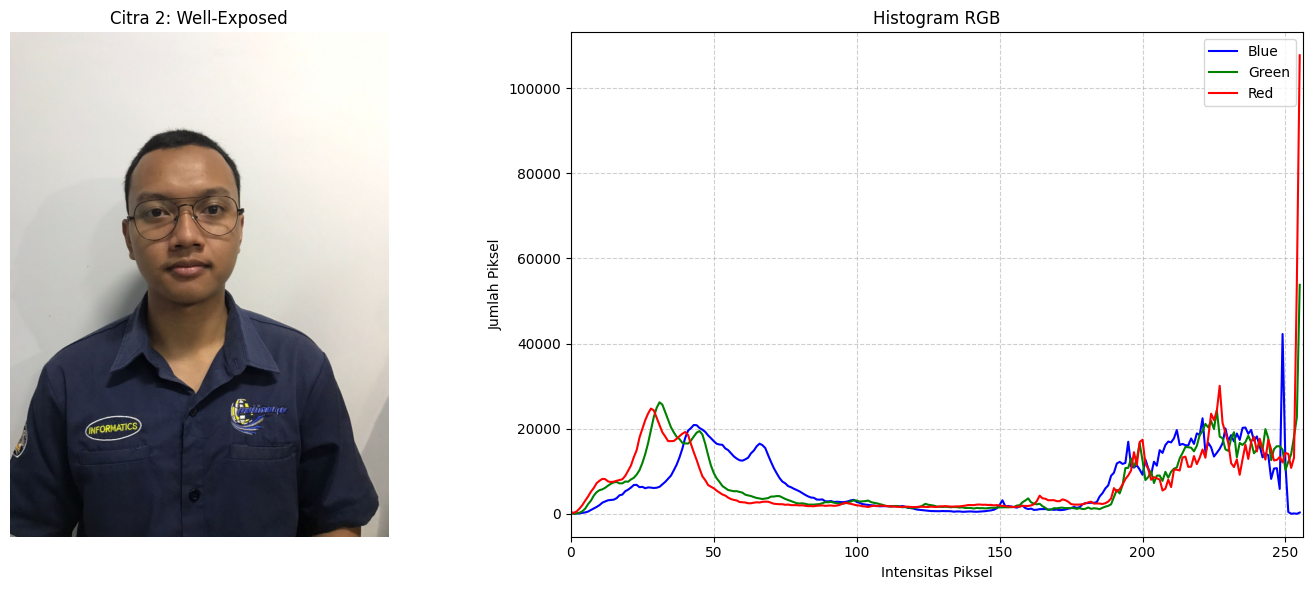

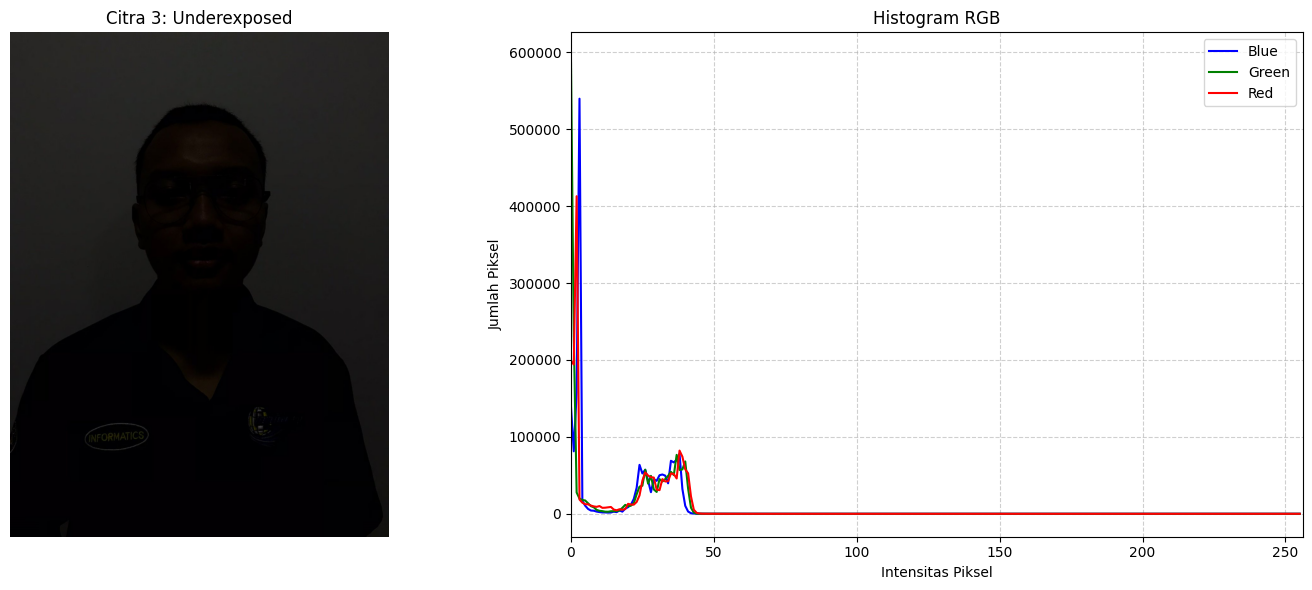

In [5]:
task_1_analyze_histograms(images)


## 2. Terapkan transformasi brightness dan contrast (linear/log brightness).



In [6]:
def task_2_adjust_brightness_contrast(images_dict):
    """
    Tugas 2: Menyesuaikan brightness/contrast tiap gambar dengan kombinasi a,b berbeda
    dan menampilkan before-after serta histogramnya.
    """
    print("\n--- 2. Transformasi Brightness & Contrast ---")

    # Kombinasi a,b untuk tiap gambar
    combinations = [
        (1.2, 10),  # untuk gambar 1
        (1.5, 20),  # untuk gambar 2
        (3, 120)     # untuk gambar 3
    ]

    images_list = list(images_dict.items())

    for i in range(len(images_list)):
        title, image = images_list[i]

        # Ambil a,b sesuai index gambar
        a, b = combinations[i]

        print(f"======================================================================================================================")
        print(f"================================= {title} (a={a}, b={b}) ===================================================")
        print(f"======================================================================================================================")
        transformed_image = cv.convertScaleAbs(image, alpha=a, beta=b)

        # Tampilkan before & after
        show_comparison(
            f"{title} - Sebelum (original)", image,
            f"{title} - Sesudah (a={a}, b={b})", transformed_image
        )

        # Tampilkan histogram
        is_gray = len(image.shape) == 2 or image.shape[2] == 1
        show_histogram_comparison(
            image, transformed_image,
            is_gray=is_gray,
            title1=f"{title} - Sebelum (original)",
            title2=f"{title} - Sesudah (a={a}, b={b})"
        )
        psnr_2 = cv.PSNR(image, transformed_image)
        print(f"PSNR: {psnr_2} dB")

### Implementasi/Hasil


--- 2. Transformasi Brightness & Contrast ---
================================= Citra 1: Side-Lighting (a=1.2, b=10) ===================================================


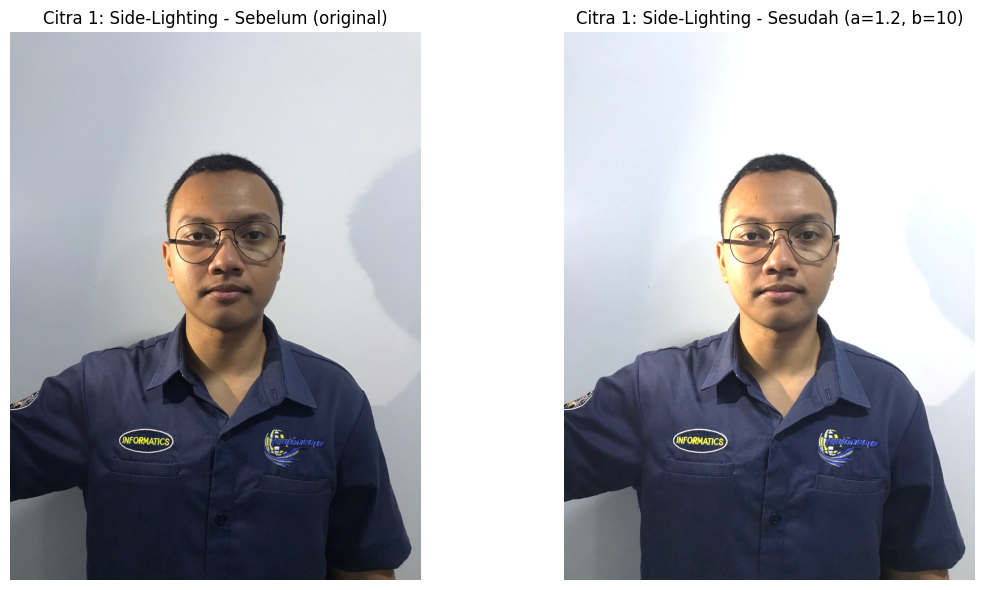

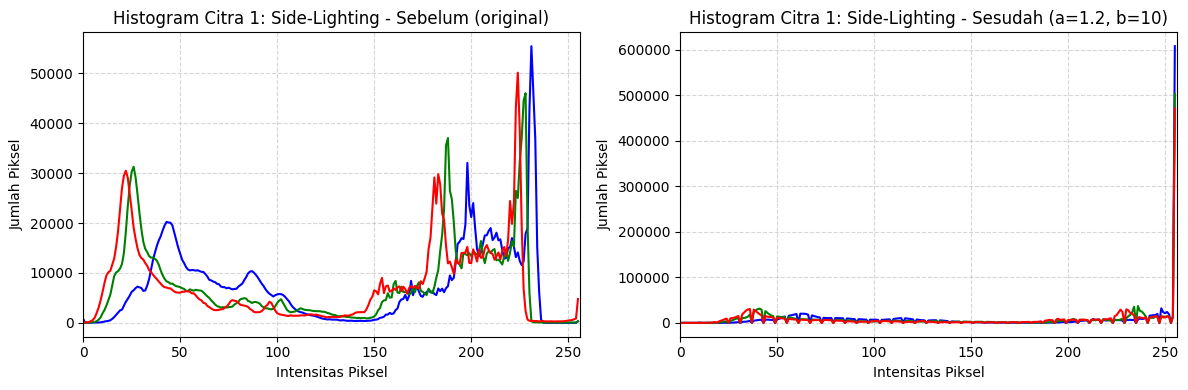

PSNR: 17.38209157248084 dB
================================= Citra 2: Well-Exposed (a=1.5, b=20) ===================================================


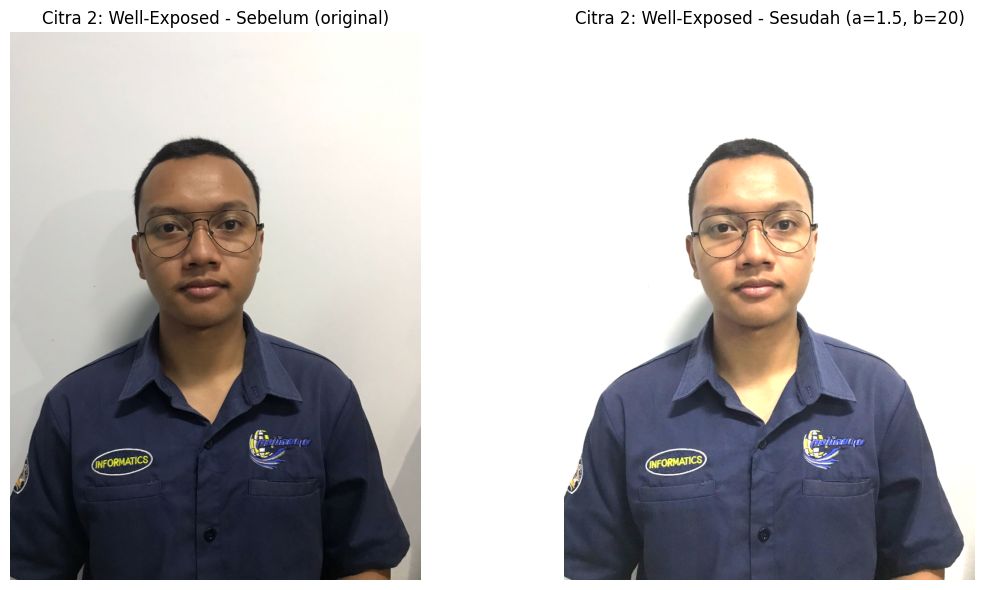

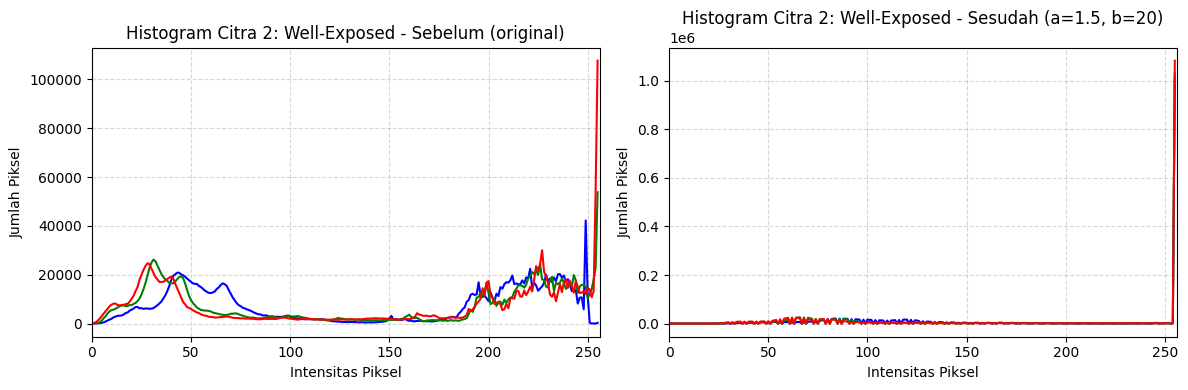

PSNR: 15.2637285039118 dB
================================= Citra 3: Underexposed (a=3, b=120) ===================================================


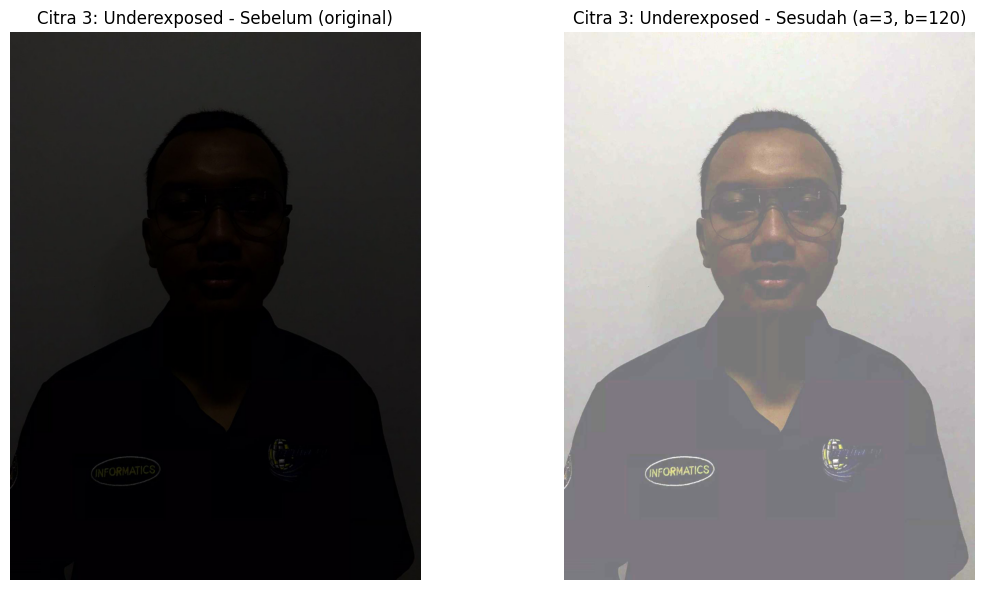

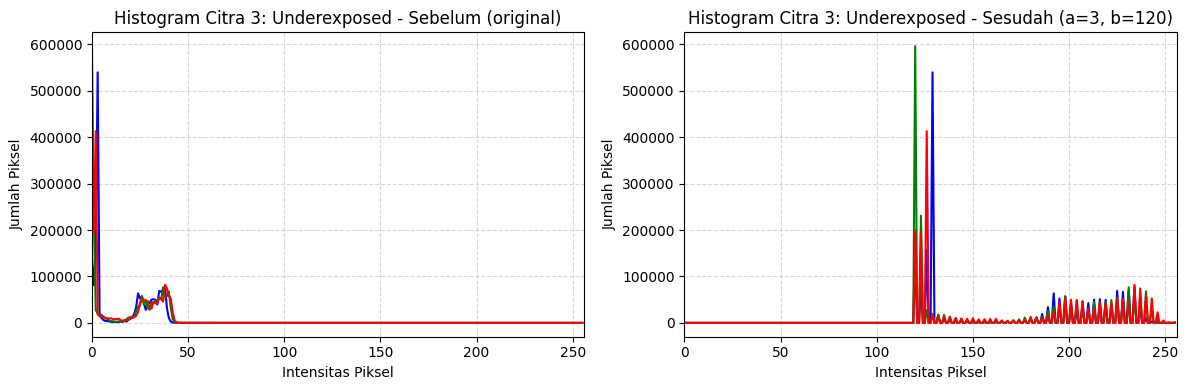

PSNR: 4.214937187084796 dB


In [7]:
task_2_adjust_brightness_contrast(images)

## 3. Lakukan histogram equalization untuk memperbaiki sebaran kontras.
Bandingkan hasil visual dan histogram sebelum–sesudah.

In [8]:
def task_3_histogram_equalization(images_dict):
    """Tugas 3: Melakukan ekualisasi pada setiap kanal B, G, R secara terpisah."""
    print("\n--- 3. Ekualisasi per Kanal Warna ---")
    for title, image in images_dict.items():
        print(f"Memproses Ekualisasi Warna: {title}")

        # Menampilkan gambar asli dan histogramnya
        print(f"================================================================== {title} =====================================================================")
        show_image_with_rgb_histogram(f"{title} - Sebelum", image)

        # 1. Pisahkan kanal B, G, R
        b, g, r = cv.split(image)

        # 2. Lakukan ekualisasi pada setiap kanal
        b_eq = cv.equalizeHist(b)
        g_eq = cv.equalizeHist(g)
        r_eq = cv.equalizeHist(r)

        # 3. Gabungkan kembali kanal-kanal yang sudah diekualisasi
        image_eq_bgr = cv.merge((b_eq, g_eq, r_eq))

        # Menampilkan gambar hasil beserta histogram barunya
        show_image_with_rgb_histogram(f"{title} - Sesudah (Equalize per Channel)", image_eq_bgr)

### Implementasi/Hasil


--- 3. Ekualisasi per Kanal Warna ---
Memproses Ekualisasi Warna: Citra 1: Side-Lighting
================================================================== Citra 1: Side-Lighting =====================================================================


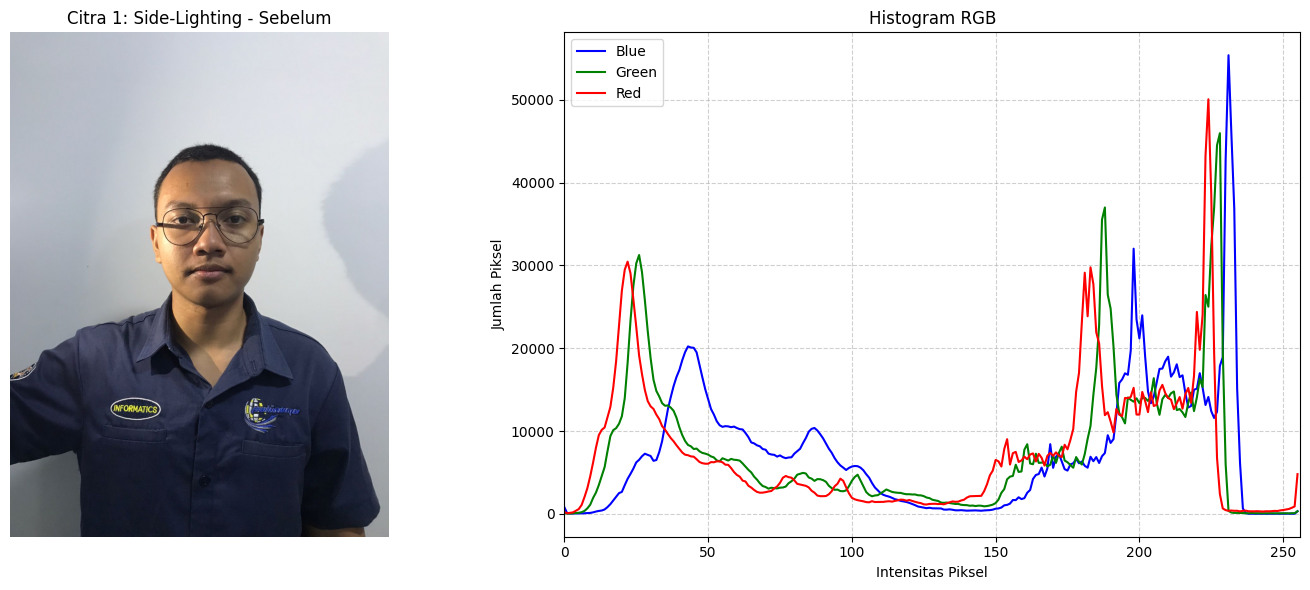

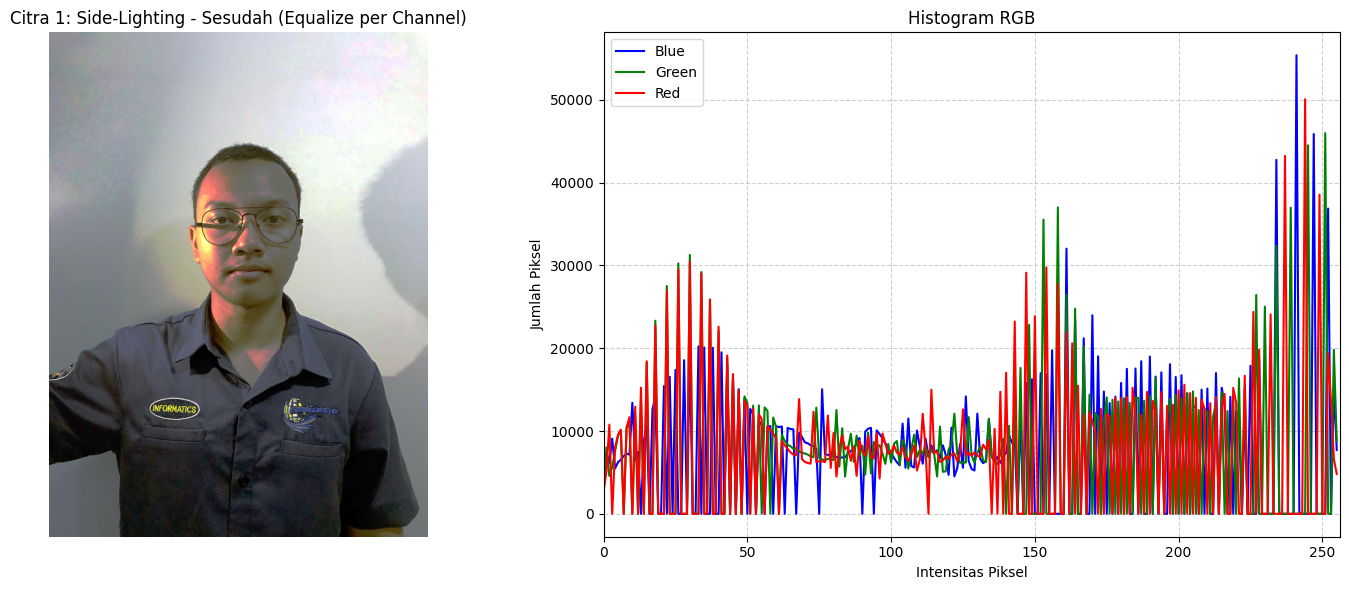

Memproses Ekualisasi Warna: Citra 2: Well-Exposed
================================================================== Citra 2: Well-Exposed =====================================================================


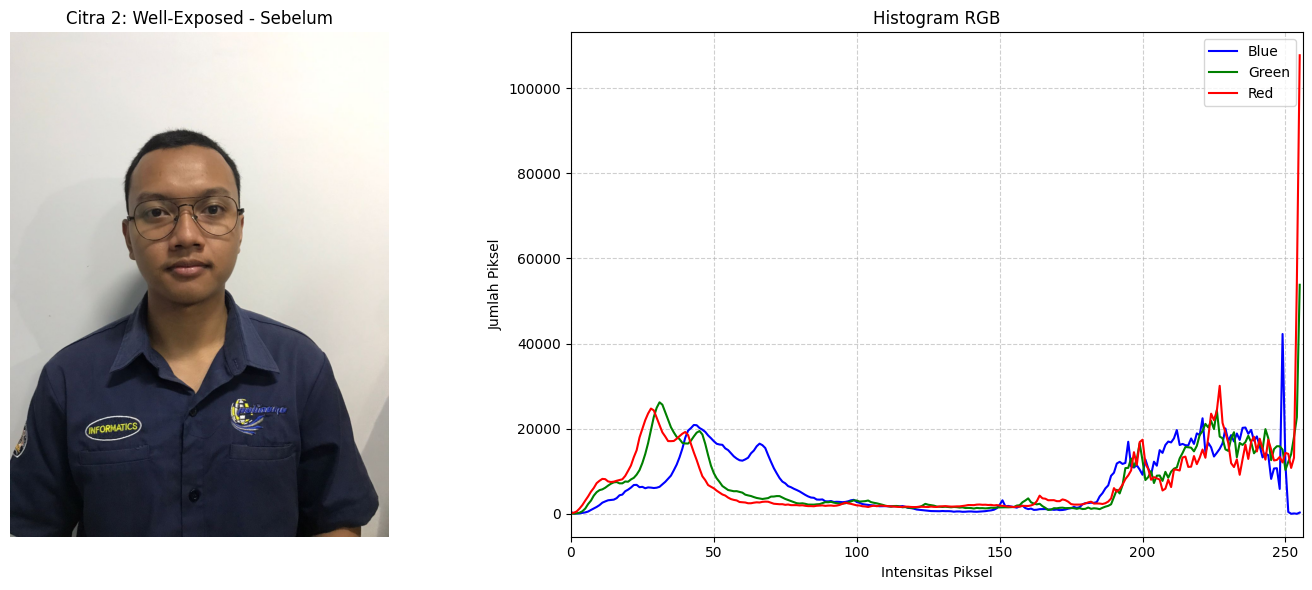

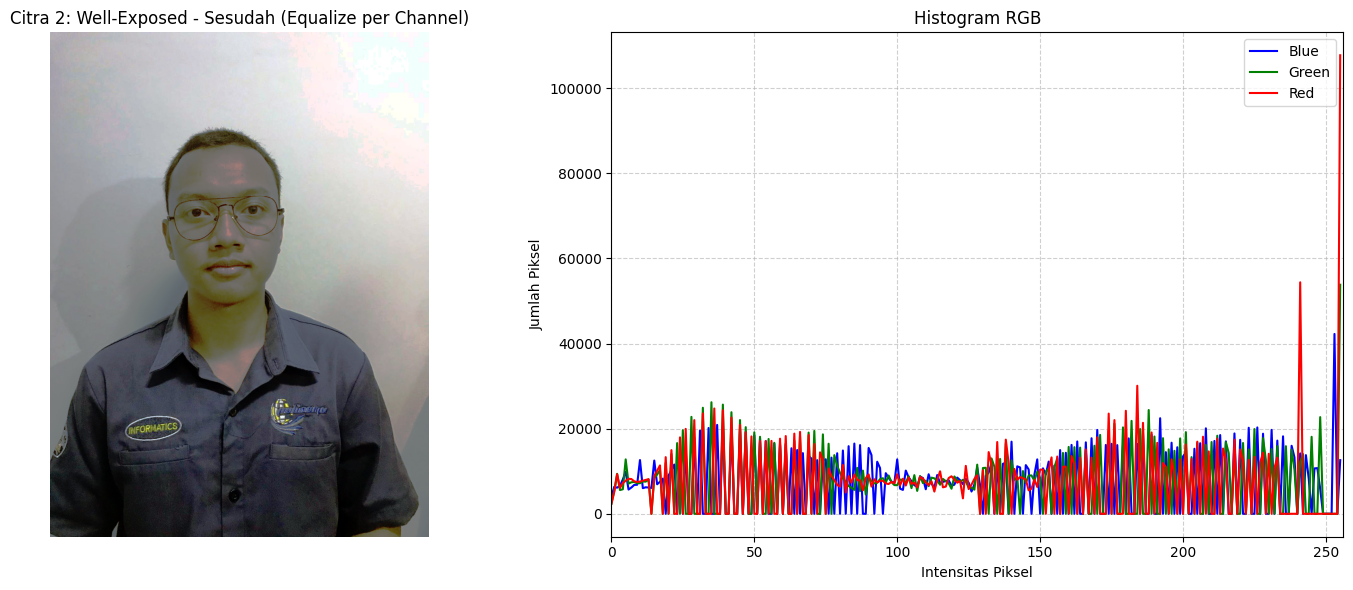

Memproses Ekualisasi Warna: Citra 3: Underexposed
================================================================== Citra 3: Underexposed =====================================================================


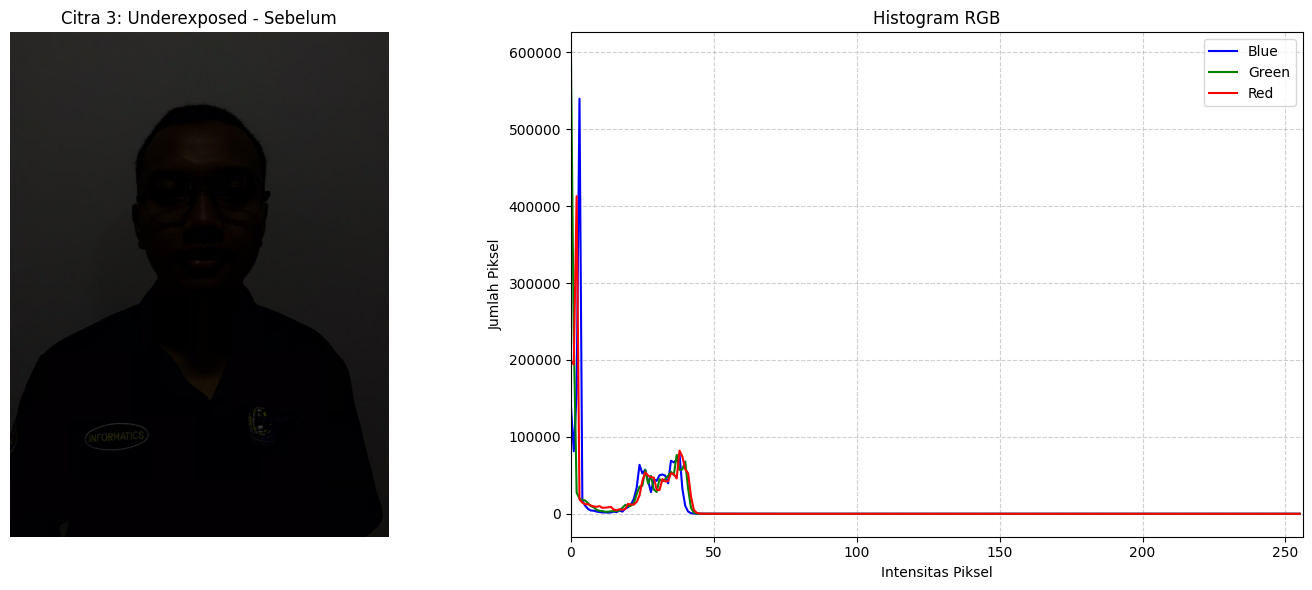

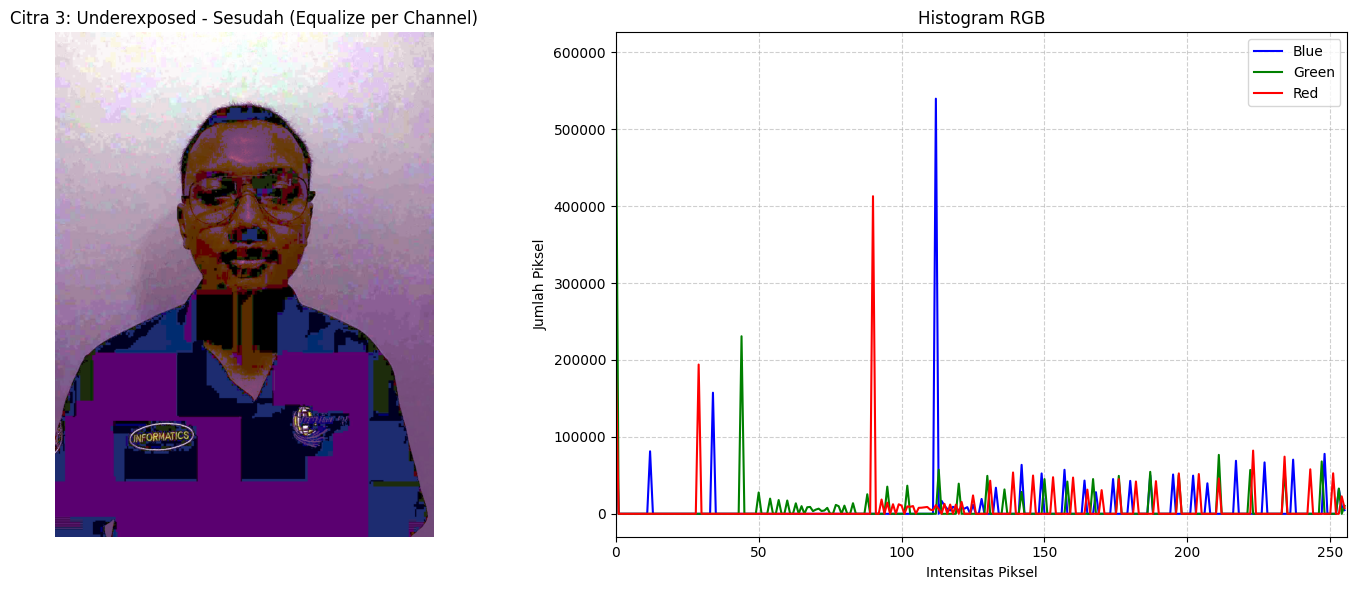

In [9]:
task_3_histogram_equalization(images)

## 4. Terapkan filter spasial:
o Low-pass filter untuk menghaluskan noise kulit wajah.<br>
o High-pass atau Laplacian filter untuk menajamkan tepi mata dan bibir.

In [16]:
def task_4_apply_spatial_filters(images_dict):
    """Tugas 4: Menerapkan filter dan menampilkan histogram hasilnya."""
    print("\n--- 4. Filter Spasial ---")
    for title, image in images_dict.items():
        print("======================================================================================================================================================================")
        print(f"================================================================== {title} ===========================================================================")
        print("=======================================================================================================================================================")
        # Menampilkan gambar asli dan histogramnya sebagai acuan
        show_image_with_rgb_histogram(f"{title} - Original", image)

        # a. Low-pass filter (smoothing) dan histogramnya
        smooth_image = cv.GaussianBlur(image, (5, 5), 1)
        show_image_with_rgb_histogram(f"{title} - Hasil Smoothing", smooth_image)
        smooth_psnr = cv.PSNR(image, smooth_image)
        print(f"PSNR Smoothing: {smooth_psnr} dB")

        # b. High-pass filter (sharpening) dan histogramnya
        laplacian = cv.Laplacian(image, cv.CV_64F)
        sharpened_image = cv.convertScaleAbs(np.float64(image) - laplacian)
        show_image_with_rgb_histogram(f"{title} - Hasil Sharpening", sharpened_image)
        charpen_psnr = cv.PSNR(image, sharpened_image)
        print(f"PSNR Sharpening: {charpen_psnr} dB")



### Implementasi/Hasil


--- 4. Filter Spasial ---
================================================================== Citra 1: Side-Lighting ===========================================================================


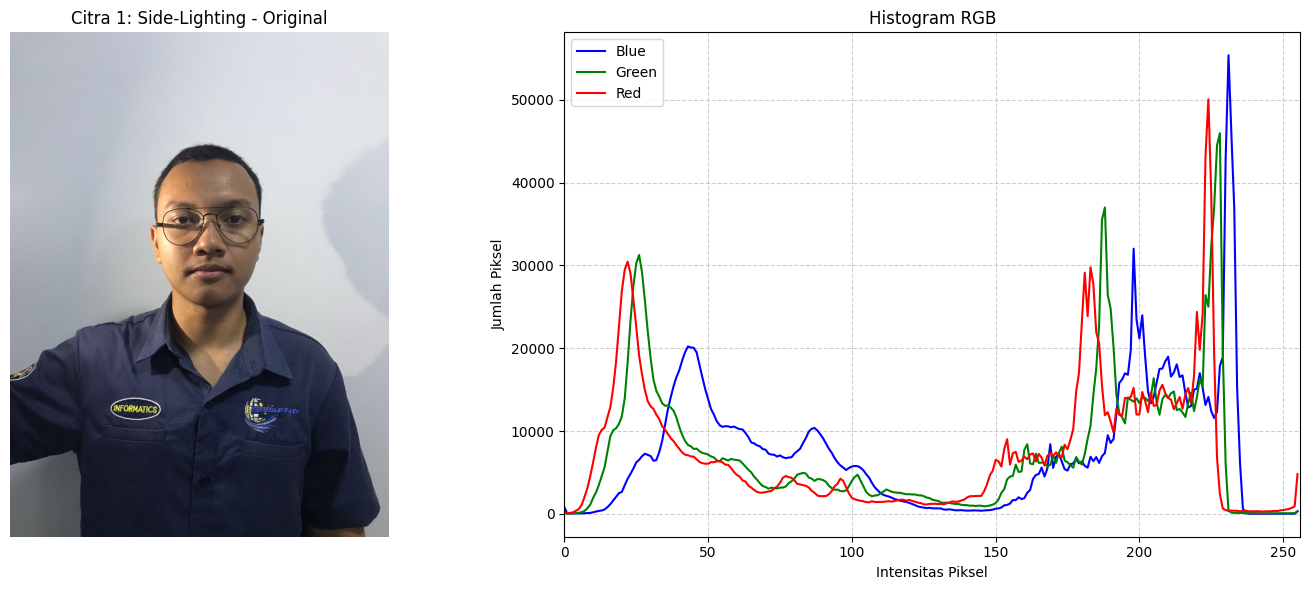

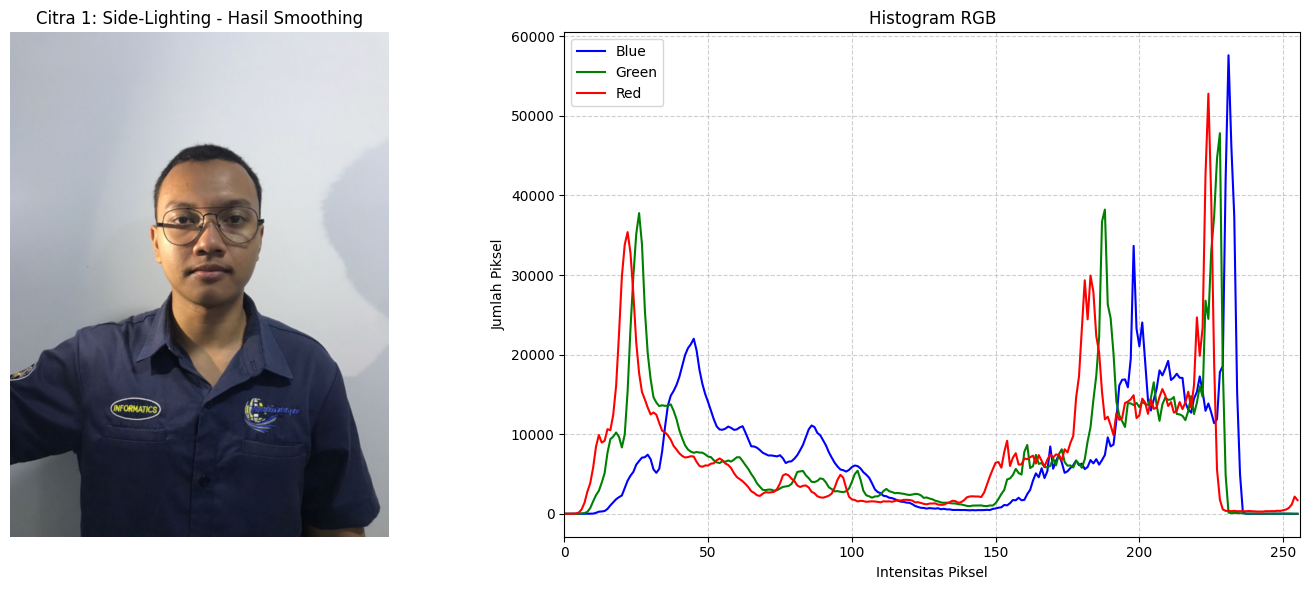

PSNR Smoothing: 38.11385723283101 dB


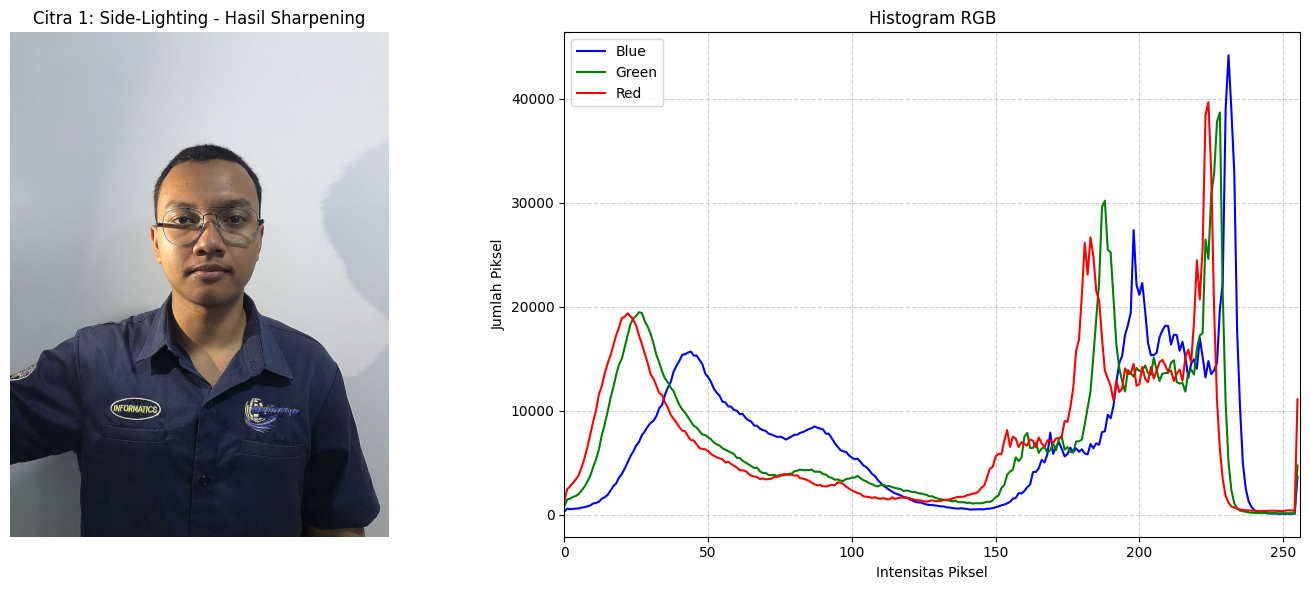

PSNR Sharpening: 29.987602557878358 dB
================================================================== Citra 2: Well-Exposed ===========================================================================


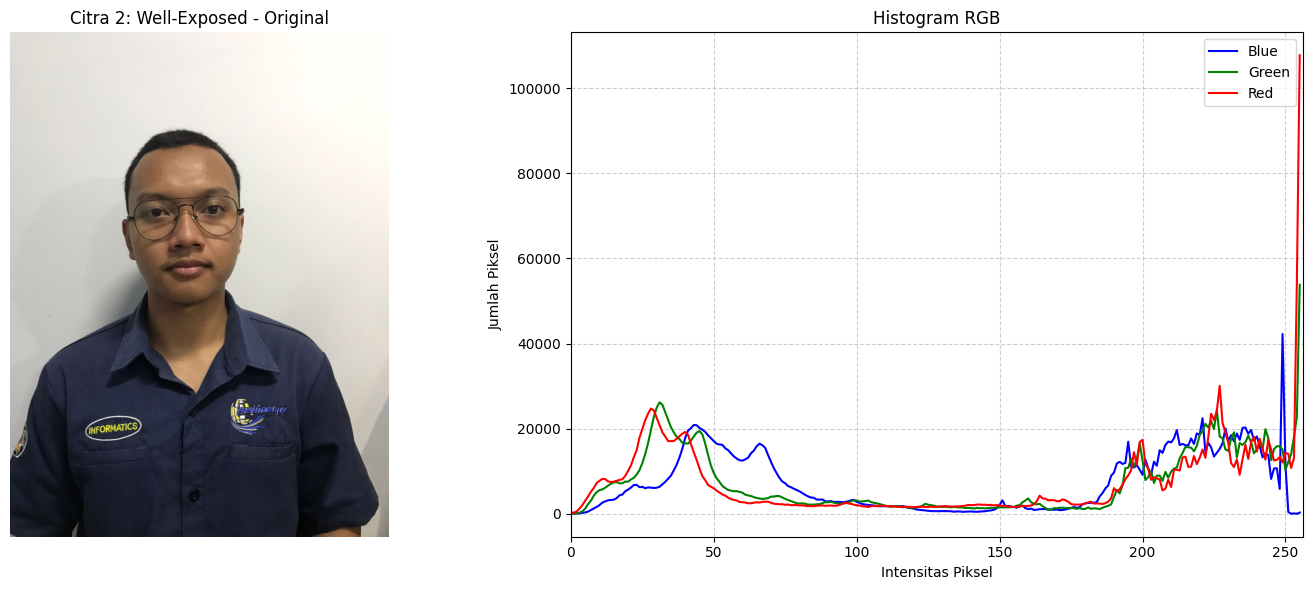

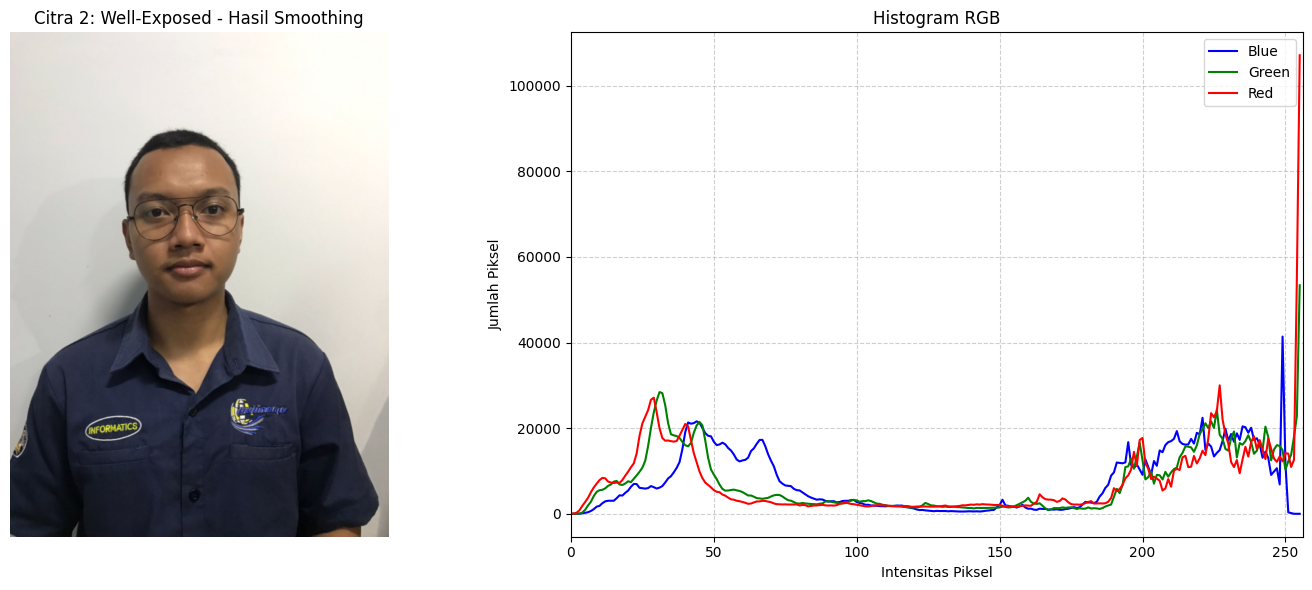

PSNR Smoothing: 40.15037390741164 dB


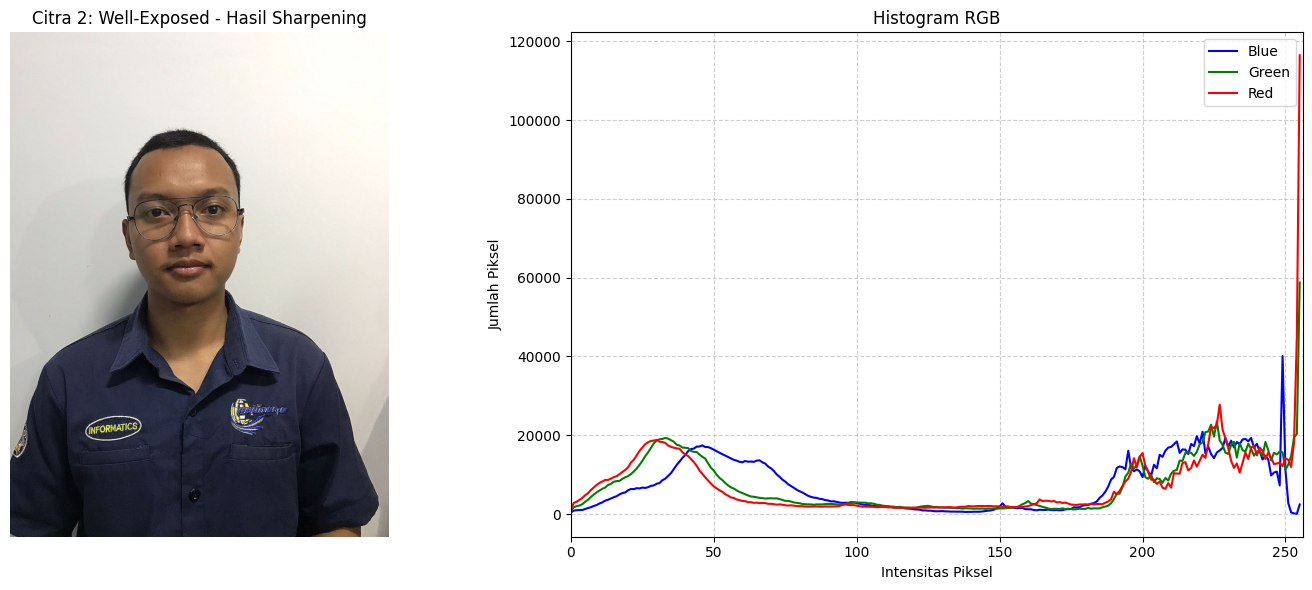

PSNR Sharpening: 32.139387404334784 dB
================================================================== Citra 3: Underexposed ===========================================================================


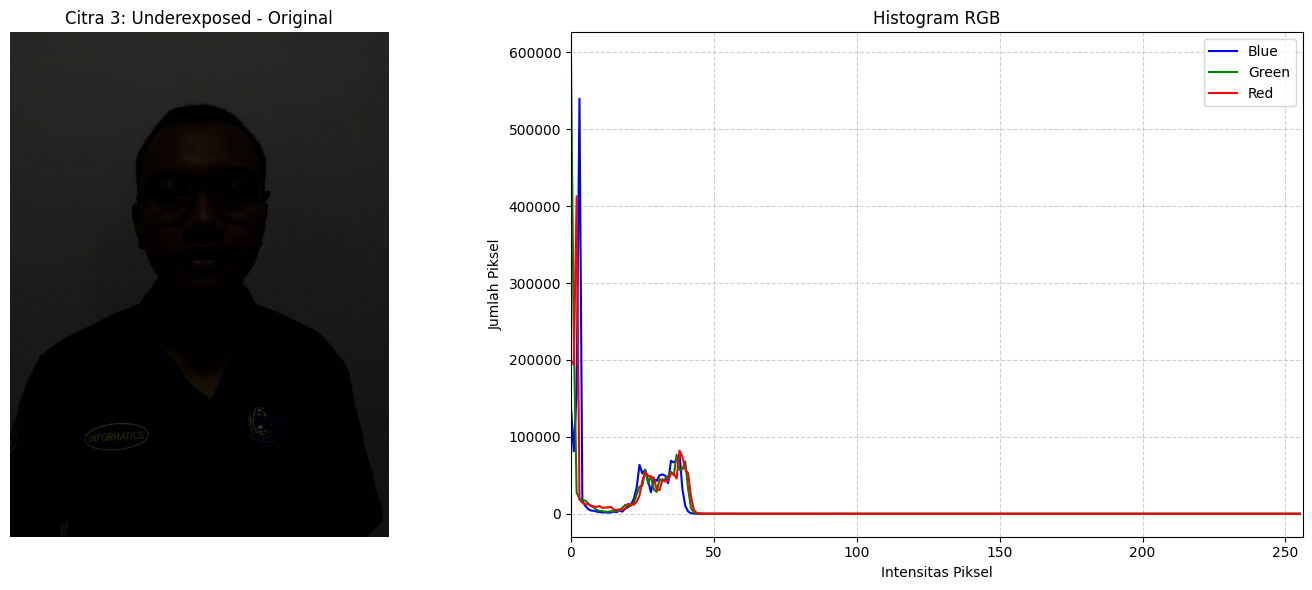

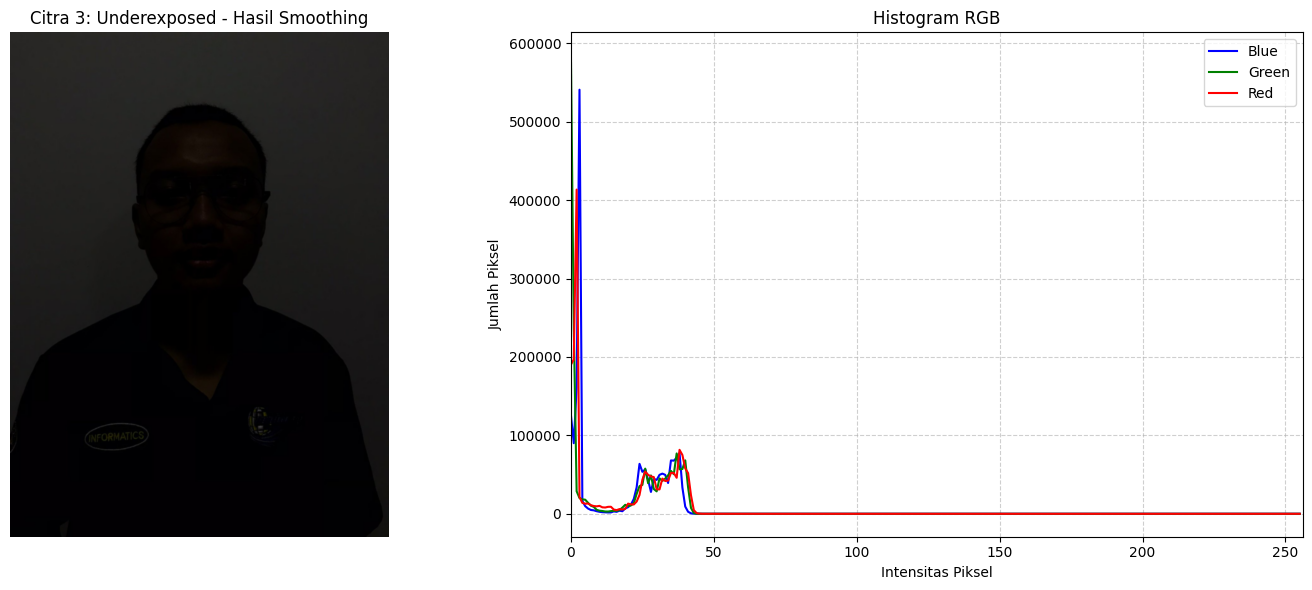

PSNR Smoothing: 53.67844387311199 dB


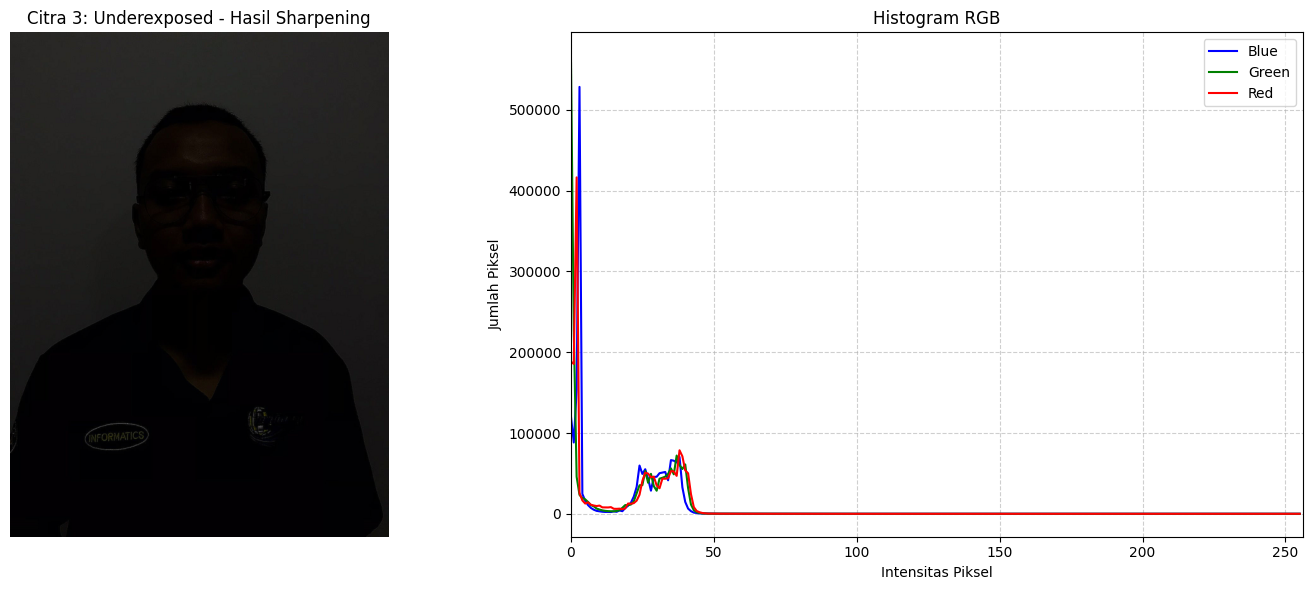

PSNR Sharpening: 44.463041642000995 dB


In [17]:
task_4_apply_spatial_filters(images)

## 5. Implementasikan Floyd–Steinberg Dithering untuk menurunkan kedalaman warna wajah (bit-depth 4–6 bit), lalu analisis bagaimana efeknya terhadap detail dan ekspresi wajah.

In [12]:
def task_5_apply_dithering(images_dict, bit_depth=4):
    """Tugas 5: Menerapkan dithering dan menampilkan histogram hasilnya."""
    print("\n--- 5. Floyd-Steinberg Dithering ---")
    for title, image in images_dict.items():
        print(f"Memproses Dithering: {title}")
        gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        # Menampilkan gambar grayscale asli dan histogramnya
        show_grayscale_and_hist(f"{title} - Grayscale Sebelum", gray_image)

        dither_image = np.float32(gray_image.copy())
        h, w = dither_image.shape
        levels = 2**bit_depth
        for y in range(h - 1):
            for x in range(1, w - 1):
                old_pixel = dither_image[y, x]
                new_pixel = np.round(old_pixel * (levels - 1) / 255) * (255 / (levels - 1))
                dither_image[y, x] = new_pixel
                quant_error = old_pixel - new_pixel
                dither_image[y, x + 1] += quant_error * 7 / 16
                dither_image[y + 1, x - 1] += quant_error * 3 / 16
                dither_image[y + 1, x] += quant_error * 5 / 16
                dither_image[y + 1, x + 1] += quant_error * 1 / 16
        dithered_final = cv.convertScaleAbs(dither_image)
        # Menampilkan gambar hasil dithering dan histogramnya
        show_grayscale_and_hist(f"{title} - Hasil Dithered ({bit_depth}-bit)", dithered_final)

### Implementasi/Hasil


--- 5. Floyd-Steinberg Dithering ---
Memproses Dithering: Citra 1: Side-Lighting


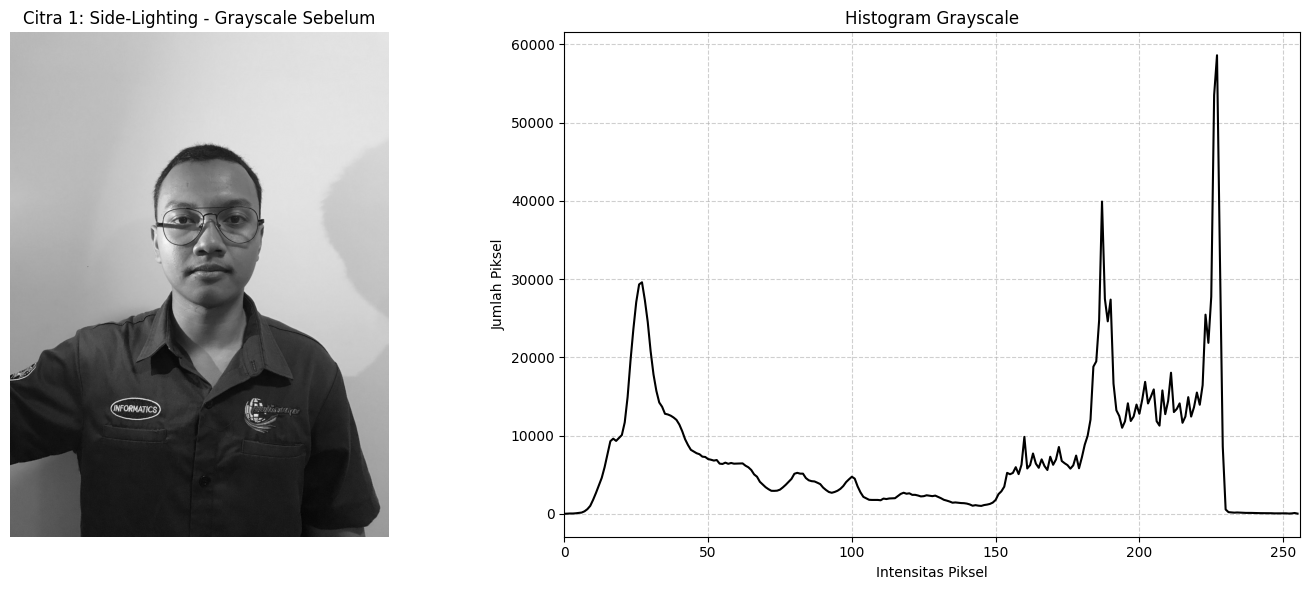

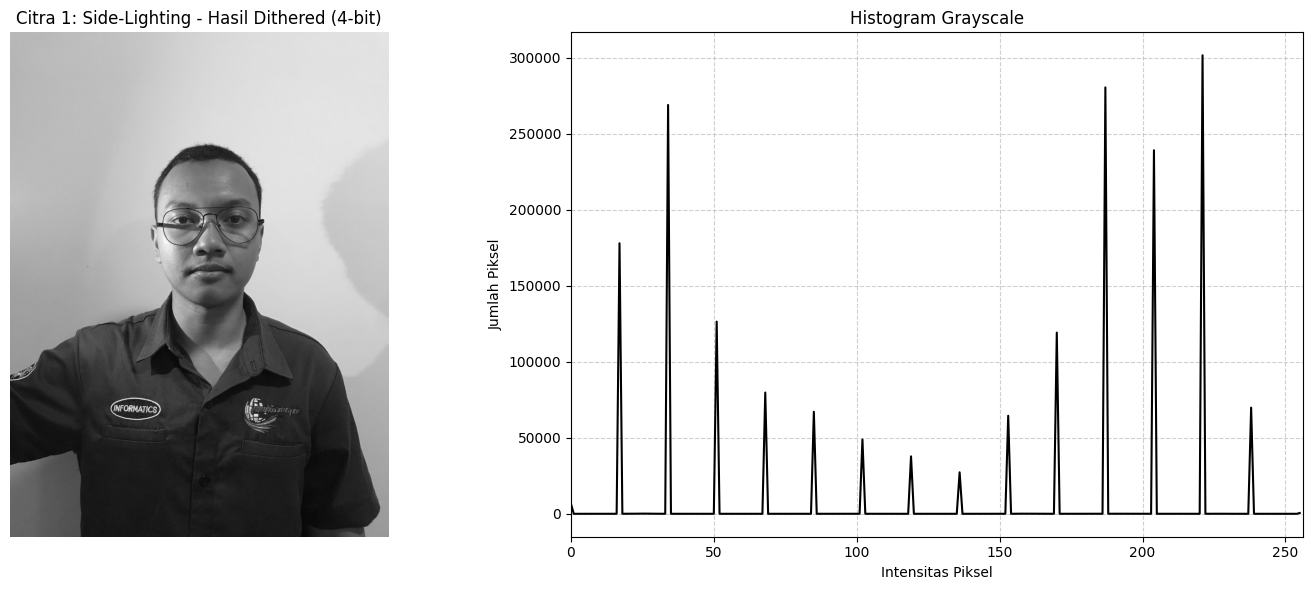

Memproses Dithering: Citra 2: Well-Exposed


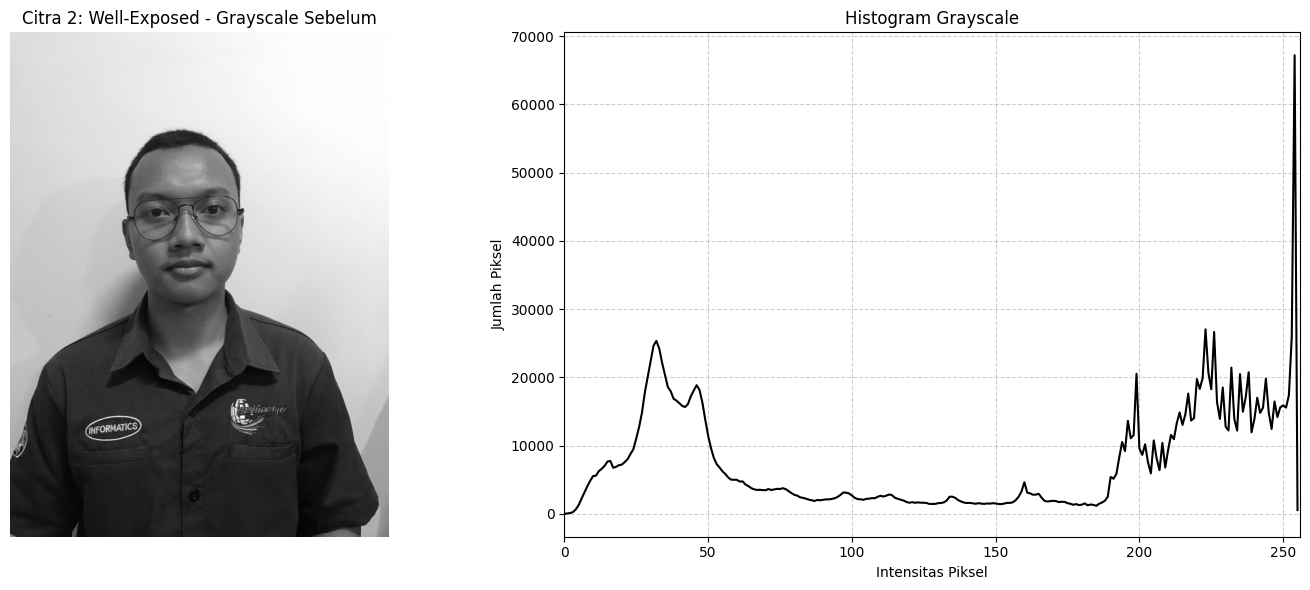

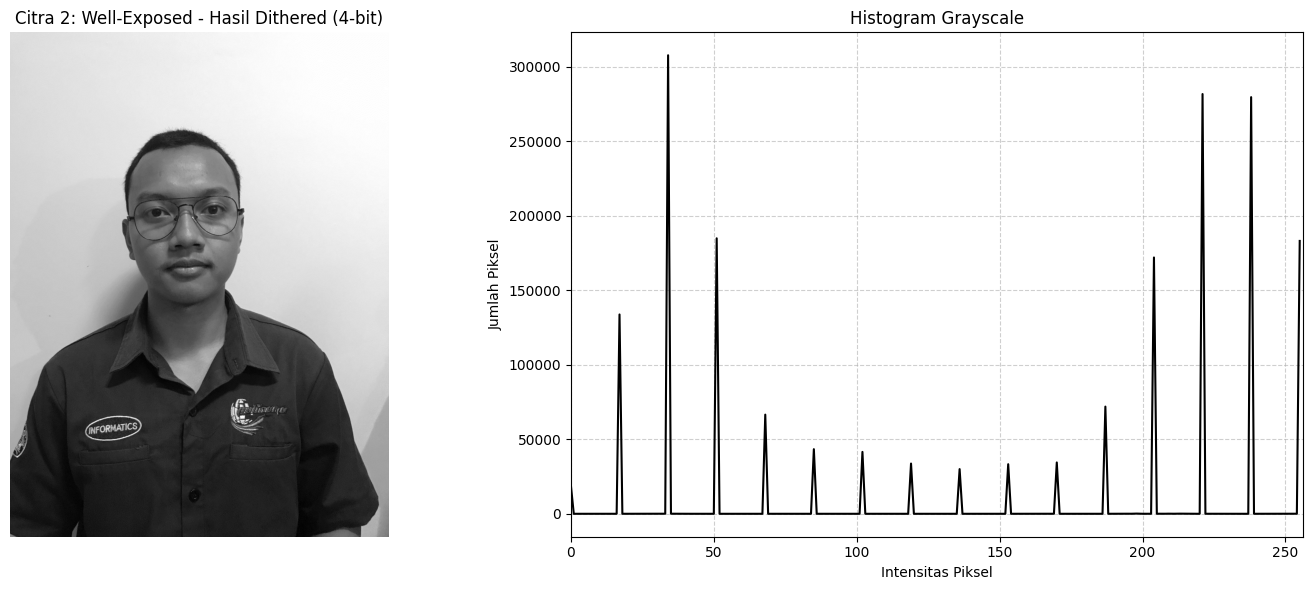

Memproses Dithering: Citra 3: Underexposed


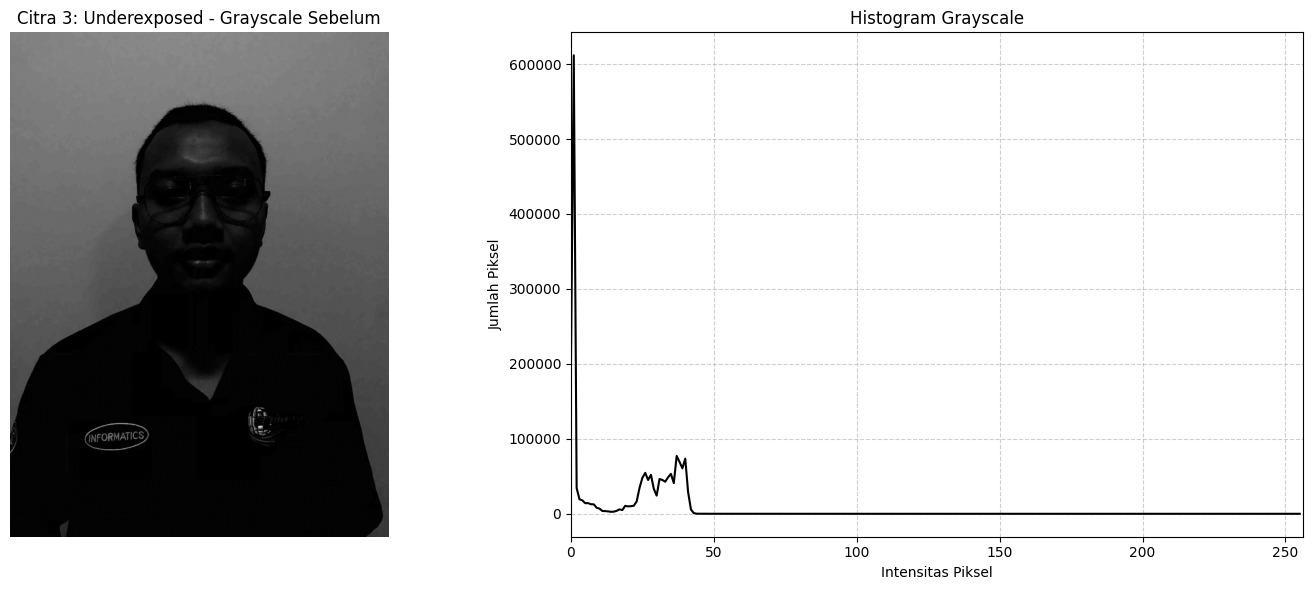

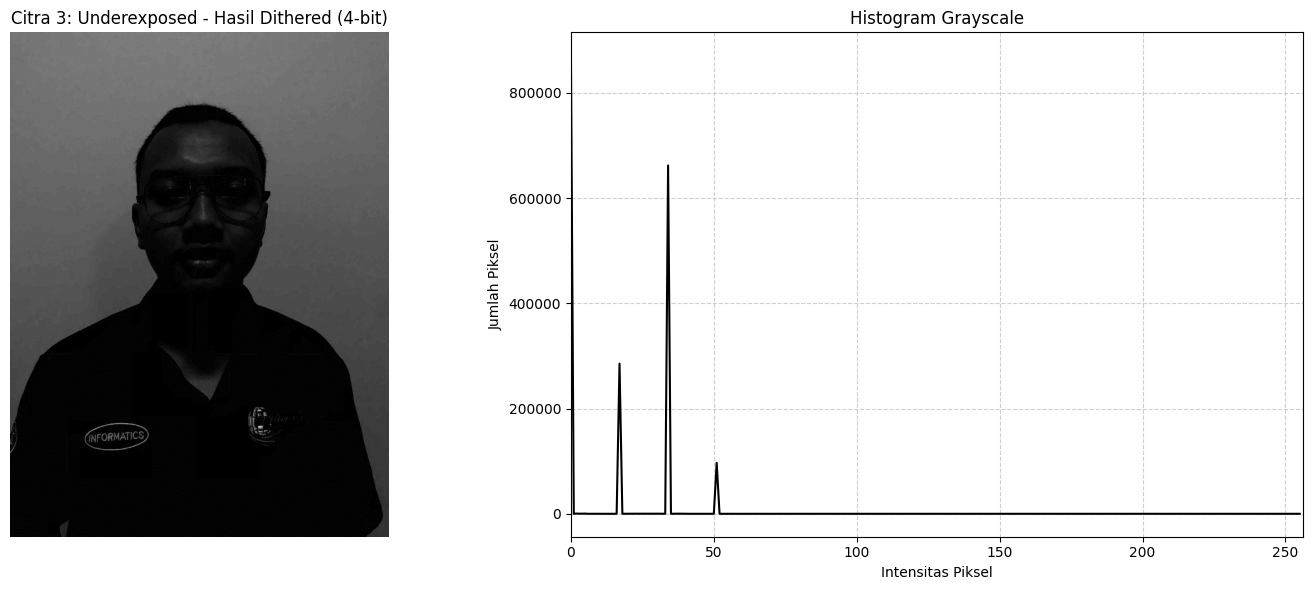

In [13]:
task_5_apply_dithering(images)

# **Bagian B – Analisis**
Jawablah dalam bentuk narasi atau tabel analisis singkat:

## 1. Bagaimana perubahan nilai brightness dan contrast memengaruhi hasil histogram wajah gelap?

Pada kondisi awal, histogram dengan jelas menunjukkan mengapa gambar terlihat sangat gelap. Seluruh data piksel menumpuk di rentang intensitas 0-50, menandakan bahwa tidak ada variasi kecerahan sama sekali; semua bagian gambar sama-sama gelap.

Setelah transformasi sesudah yang baru, histogramnya menunjukkan perubahan dramatis. Penambahan brightness yang masif (b=120) telah menggeser seluruh data piksel dari area gelap ke area terang. Selanjutnya, contrast yang sangat tinggi (a=3.0) meregangkan data yang sudah bergeser tersebut secara paksa ke seluruh penjuru histogram.

## 2. Apakah histogram equalization selalu memperbaiki detail wajah?
Jelaskan alasannya dengan contoh hasil Anda.

Tidak, histogram equalization tidak selalu memperbaiki detail wajah.

Ekualisasi per kanal warna (R, G, B) merusak keseimbangan warna asli pada gambar, sehingga menghasilkan corak warna (color cast) yang tidak natural dan justru mengaburkan detail.

* Gambar Sebelum: Menampilkan warna yang seimbang dan natural. Warna kulit
terlihat wajar, kemeja berwarna biru, dan latar belakang berwarna putih keabuan. Detail wajah dapat dilihat dengan jelas.

* Gambar Sesudah: Gambar didominasi oleh corak warna hijau-kekuningan yang kuat. Warna kulit menjadi tidak realistis, dan latar belakang yang seharusnya netral kini berwarna. Perubahan warna yang drastis ini mengganggu persepsi kita terhadap detail wajah yang sebenarnya. Alih-alih memperbaiki, efek ini justru membuat gambar terlihat lebih buruk.

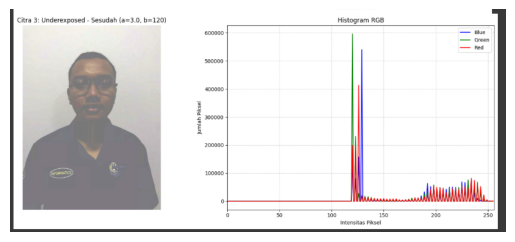

In [14]:
path_gambar = '/content/drive/MyDrive/Case_Method_IMG/pcvk_case_study_img/Screenshot 2025-10-06 132838.png'

img_bgr = cv.imread(path_gambar)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## 3. Bandingkan hasil low-pass dan high-pass filter pada area wajah — bagian mana yang paling terpengaruh?

*Low-Pass Filter (Hasil Smoothing)*

Filter ini bekerja dengan cara "meratakan" nilai sebuah piksel dengan piksel-piksel di sekitarnya. Akibatnya, perubahan warna yang drastis dan detail berfrekuensi tinggi (seperti tekstur kulit atau bintik kecil) akan menjadi kabur atau hilang.

Pada Contoh: Perhatikan area pipi dan dahi pada gambar "Hasil Smoothing". Tekstur kulit yang semula terlihat wajar kini menjadi jauh lebih mulus, seolah-olah menggunakan efek soft focus. Inilah area yang paling terpengaruh karena filter ini menargetkan detail-detail kecil tersebut.

*High-Pass Filter (Hasil Sharpening)*

Filter ini adalah kebalikannya; ia mencari "tepian" atau area di mana ada perubahan warna yang signifikan. Hasil deteksi tepi ini kemudian ditambahkan kembali ke gambar asli untuk membuat tepian tersebut semakin kontras.

Pada Contoh Anda: Lihatlah bingkai kacamata pada gambar "Hasil Sharpening". Garis hitamnya terlihat lebih tegas dan tajam dibandingkan gambar original. Begitu pula dengan garis bibir dan kontur mata yang menjadi lebih jelas. Bagian inilah yang paling terpengaruh karena memiliki transisi warna yang paling tajam.

*Pengaruh pada Histogram*

* Smoothing: Puncak-puncak histogram menjadi sedikit lebih sempit dan halus
karena variasi piksel berkurang.

* Sharpening: Distribusi histogram menjadi sedikit lebih lebar karena proses penajaman menciptakan piksel-piksel yang lebih gelap dan lebih terang di sepanjang tepian, sehingga meningkatkan variasi intensitas.**3. Bandingkan hasil low-pass dan high-pass filter pada area wajah — bagian mana yang paling
terpengaruh?**

*Low-Pass Filter (Hasil Smoothing)*

Filter ini bekerja dengan cara "meratakan" nilai sebuah piksel dengan piksel-piksel di sekitarnya. Akibatnya, perubahan warna yang drastis dan detail berfrekuensi tinggi (seperti tekstur kulit atau bintik kecil) akan menjadi kabur atau hilang.

Pada Contoh: Perhatikan area pipi dan dahi pada gambar "Hasil Smoothing". Tekstur kulit yang semula terlihat wajar kini menjadi jauh lebih mulus, seolah-olah menggunakan efek soft focus. Inilah area yang paling terpengaruh karena filter ini menargetkan detail-detail kecil tersebut.

*High-Pass Filter (Hasil Sharpening)*

Filter ini adalah kebalikannya; ia mencari "tepian" atau area di mana ada perubahan warna yang signifikan. Hasil deteksi tepi ini kemudian ditambahkan kembali ke gambar asli untuk membuat tepian tersebut semakin kontras.

Pada Contoh Anda: Lihatlah bingkai kacamata pada gambar "Hasil Sharpening". Garis hitamnya terlihat lebih tegas dan tajam dibandingkan gambar original. Begitu pula dengan garis bibir dan kontur mata yang menjadi lebih jelas. Bagian inilah yang paling terpengaruh karena memiliki transisi warna yang paling tajam.

*Pengaruh pada Histogram*

* Smoothing: Puncak-puncak histogram menjadi sedikit lebih sempit dan halus
karena variasi piksel berkurang.

* Sharpening: Distribusi histogram menjadi sedikit lebih lebar karena proses penajaman menciptakan piksel-piksel yang lebih gelap dan lebih terang di sepanjang tepian, sehingga meningkatkan variasi intensitas.

## 4. Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?


Dithering memperkuat struktur utama sebuah ekspresi dengan cara meningkatkan kontras lokal. Saat kedalaman warna dikurangi, setiap area gambar "dipaksa" untuk diwakili oleh sejumlah warna terbatas (misalnya, hanya 16 level abu-abu).

*Efek pada Wajah: Ini membuat garis-garis penting yang membentuk ekspresi menjadi sangat jelas.*

* Garis Senyum atau Kerutan Dahi: Bayangan dari lipatan senyum atau kerutan dahi menjadi area berpola gelap yang sangat kontras dengan area kulit yang lebih terang di sekitarnya.

* Bentuk Mata dan Bibir: Kontur atau garis luar mata dan bibir dipertahankan dengan baik dan bahkan bisa terlihat lebih tajam karena perbedaan drastis antara piksel terang dan gelap.

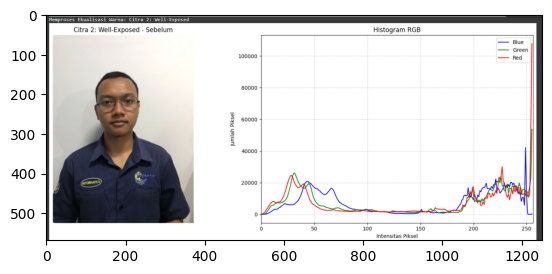

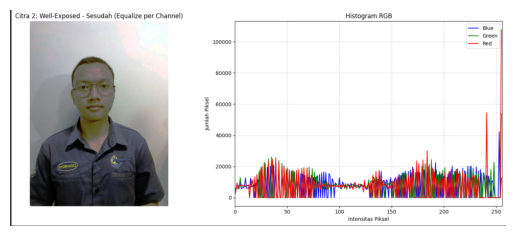

In [15]:
path_gambar = '/content/drive/MyDrive/Case_Method_IMG/pcvk_case_study_img/Screenshot 2025-10-06 133552.png'
path_gambar2 = '/content/drive/MyDrive/Case_Method_IMG/pcvk_case_study_img/Screenshot 2025-10-06 133605.png'

img_bgr = cv.imread(path_gambar)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

img_bgr2 = cv.imread(path_gambar2)
img_rgb2 = cv.cvtColor(img_bgr2, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()
plt.imshow(img_rgb2)
plt.axis('off')
plt.show()

## 5. Berdasarkan hasil percobaan Anda, kombinasi teknik mana yang paling efektif untuk meningkatkan readability fitur wajah sebelum tahap deteksi?

### *Skenario 1: Citra Gelap / Underexposed (Hasil pada Citra 3)*
Untuk gambar ini, tujuannya adalah memunculkan fitur wajah dari kegelapan.

*Teknik yang Efektif:*

*Brightness & Contrast:* Meskipun hasilnya overexposed dan kasar, teknik ini berhasil membuat wajah yang semula tidak terlihat menjadi jelas. Ini adalah langkah pertama yang paling penting.

*Histogram Equalization:* Sama seperti di atas, metode ini juga berhasil mengangkat detail dari bayangan, meskipun dengan risiko perubahan warna yang signifikan.

*Teknik yang Kurang Efektif:*

*Filter Spasial:* Menerapkan sharpening pada gambar gelap ini hampir tidak memberikan efek apa pun karena tidak ada detail atau tepi yang cukup jelas untuk dipertajam.

*Kombinasi Terbaik untuk Skenario Ini:*

* Langkah 1: Peningkatan Kontras Ekstrem. Gunakan teknik seperti Brightness/Contrast dengan nilai tinggi atau Histogram Equalization untuk "menyelamatkan" gambar.

* Langkah 2: Penajaman (Sharpening). Setelah wajah terlihat, baru terapkan sharpening untuk mempertegas fitur.



### *Skenario 2: Citra dengan Pencahayaan Baik (Hasil pada Citra 1 & Citra 2)*
Untuk gambar ini, tujuannya adalah mempertegas fitur yang sudah terlihat jelas.

*Teknik yang Efektif:*

*Filter Spasial - Sharpening:* Ini adalah satu-satunya teknik yang benar-benar meningkatkan readability fitur wajah. Tepi kacamata, mata, dan bibir menjadi lebih tajam dan lebih mudah dideteksi.

*Teknik yang Justru Merusak:*

*Brightness & Contrast:* Menerapkan ini pada gambar yang sudah terang adalah sebuah kesalahan. Hasilnya adalah gambar yang sangat putih, overexposed, dan kehilangan banyak sekali detail.

*Histogram Equalization:* Seperti yang kita lihat sebelumnya, ini menyebabkan perubahan warna drastis (menjadi hijau-kuning), membuat gambar tidak natural dan justru mengganggu proses deteksi.

*Kombinasi Terbaik untuk Skenario Ini:*

*Filter Spasial (Sharpening).* Ini adalah metode yang paling langsung dan efektif untuk mempertajam fitur yang sudah ada.

# **Bagian D – Analisis Akhir & Kesimpulan**
Tuliskan 1 halaman analisis:<br>
• Urutan proses terbaik untuk menghasilkan wajah paling siap recognition <br>
• Perbandingan nilai PSNR antara citra asli yang memiliki pencahanyaan baik dan hasil pra-pemrosesan <br>
• Rekomendasi metode peningkatan kualitas wajah untuk sistem pengenalan wajah real-time

## **Urutan Proses (Pipeline) Terbaik untuk Menghasilkan Wajah Paling Siap Recognition**
Urutan proses yang paling robust adalah pipeline adaptif yang terlebih dahulu menganalisis kondisi pencahayaan citra, kemudian menerapkan serangkaian tindakan yang sesuai.

Input Citra Wajah.

Tahap 1: Analisis Pencahayaan. Langkah pertama adalah memeriksa histogram atau intensitas rata-rata piksel pada citra. Berdasarkan analisis ini, citra diklasifikasikan sebagai underexposed (gelap) atau well-lit (pencahayaan baik).

Tahap 2: Normalisasi Kondisi Citra (Bercabang):

Jika Citra Underexposed:

Langkah A: Peningkatan Kontras Adaptif (CLAHE). Dari semua metode ekualisasi, CLAHE terbukti paling efektif. Teknik ini mampu mengangkat detail dari area gelap secara lokal tanpa merusak keseimbangan warna atau memperkuat noise secara berlebihan, menghasilkan citra yang jauh lebih natural dibandingkan equalizeHist global.

Langkah B: Penajaman (Sharpening). Setelah detail wajah terlihat, terapkan filter high-pass (sharpening) untuk mempertegas kontur mata, hidung, dan bibir.

Jika Citra Well-Lit:

Langkah A (Opsional): Penghalusan (Smoothing). Terapkan filter low-pass (misalnya, Gaussian Blur dengan kernel kecil) untuk menghilangkan noise minor pada kulit. Langkah ini mencegah noise diperkuat pada tahap selanjutnya.

Langkah B: Penajaman (Sharpening). Ini adalah langkah paling penting untuk citra yang sudah baik. Menerapkan filter high-pass secara langsung akan secara signifikan meningkatkan ketajaman fitur-fitur kunci yang dibutuhkan oleh model recognition.

Output: Citra wajah yang ternormalisasi dan siap untuk tahap ekstraksi fitur.

## **Perbandingan Nilai PSNR**
PSNR (Peak Signal-to-Noise Ratio) adalah metrik yang mengukur seberapa mirip sebuah citra hasil pemrosesan dengan citra aslinya. Nilai PSNR yang tinggi berarti kedua citra sangat mirip (sedikit "error" atau "noise" yang ditambahkan).

Saat membandingkan citra asli dengan pencahayaan baik (Citra 2 - Original) dengan hasil prapemrosesan terbaiknya (yaitu, hasil sharpening), kita akan menemukan sebuah paradoks: nilai PSNR-nya justru akan relatif rendah.

Alasannya:
Tujuan prapemrosesan untuk recognition bukanlah untuk menghasilkan citra yang identik dengan aslinya. Tujuannya adalah untuk memanipulasi citra agar fitur-fitur penting menjadi lebih menonjol bagi mesin. Proses sharpening secara sengaja mengubah nilai piksel di sekitar tepi untuk meningkatkan kontras lokal. Perubahan ini, dari sudut pandang matematis, adalah "error" atau "noise" jika dibandingkan dengan citra asli, sehingga menurunkan nilai PSNR.

Dengan kata lain, PSNR yang rendah dalam konteks ini bukanlah indikasi kegagalan. Sebaliknya, ini menunjukkan bahwa filter telah berhasil melakukan tugasnya dalam memodifikasi citra untuk menonjolkan fitur. Metrik yang lebih tepat untuk mengukur keberhasilan di sini adalah akurasi dari sistem pengenalan wajah itu sendiri, bukan PSNR.

## **Rekomendasi untuk Sistem Pengenalan Wajah Real-Time**
Sistem real-time (misalnya, absensi wajah via webcam) memiliki batasan utama: kecepatan komputasi. Setiap frame dari video harus diproses dalam hitungan milidetik.

Berdasarkan hal tersebut, rekomendasi metode yang paling seimbang antara efektivitas dan kecepatan adalah:

Kombinasi Linear Brightness/Contrast + Spatial Filtering (Sharpening).

Alasan:

Kecepatan: Transformasi linear (g(x,y) = a*f(x,y) + b) dan filter spasial dengan kernel kecil (konvolusi) adalah operasi yang sangat cepat dan telah dioptimalkan dalam library seperti OpenCV.

Efektivitas: Kombinasi ini mampu menangani dua masalah utama: pencahayaan yang buruk (dengan penyesuaian linear) dan ketajaman fitur (dengan sharpening).

Praktikalitas: Metode seperti CLAHE, meskipun kualitasnya superior, secara komputasi lebih berat karena harus bekerja pada banyak "tile" gambar. Untuk sistem real-time berkecepatan tinggi, ini bisa menjadi bottleneck. Dithering sama sekali tidak direkomendasikan karena prosesnya yang iteratif dan lambat.

Pipeline Real-Time yang Direkomendasikan:

Tangkap frame dari video.

Lakukan deteksi wajah.

Hitung intensitas rata-rata pada area wajah yang terdeteksi (operasi yang sangat cepat).

Jika intensitas di bawah ambang batas, terapkan penyesuaian brightness/contrast linear.

Selalu terapkan filter sharpening dengan kernel kecil (misal, 3x3).

Kirim wajah yang telah diproses ke model recognition.